# Libraries



In [58]:
import numpy as np
import pandas as pd
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import re
nltk.download('punkt_tab')
from nltk.corpus import stopwords   #Stopword removal
from nltk.stem import PorterStemmer   #Stemming
from nltk.stem import WordNetLemmatizer   # Lemmatization

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Reading Files

In [5]:
df_fake = pd.read_csv("/content/drive/MyDrive/Fake_real/Fake.csv")
df_real = pd.read_csv("/content/drive/MyDrive/Fake_real/True.csv")

#EDA

In [6]:
df_fake.shape

(23481, 4)

In [7]:
df_real.shape

(21417, 4)

In [8]:
# The number of fake news are larger than real news

In [9]:
df_fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [10]:
df_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [11]:
df_fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [12]:
df_real.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [13]:
#  There is no missing value

In [14]:
df_fake.head()


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [15]:
df_real.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [16]:
df_fake['label'] = 0
df_real['label'] = 1

In [17]:
print(df_fake['label'].value_counts())
print(df_real['label'].value_counts())

label
0    23481
Name: count, dtype: int64
label
1    21417
Name: count, dtype: int64


In [18]:
# Merging datasets
df = pd.concat([df_fake, df_real], axis=0)

In [19]:
df = df.reset_index(drop=True)

In [20]:
print(df.shape)
display(df.head())

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [21]:
# Shuffling dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [22]:
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


1. Yes. Fake and real article varies differently in the content and way of writing and length.
2. they contain symbols capitalised words and numbers which may be removed
3. for proper classification of news as fake and real a class balance is needed. if there is imbalance then the result will be biased

#Preprocessing

In [23]:
print(df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


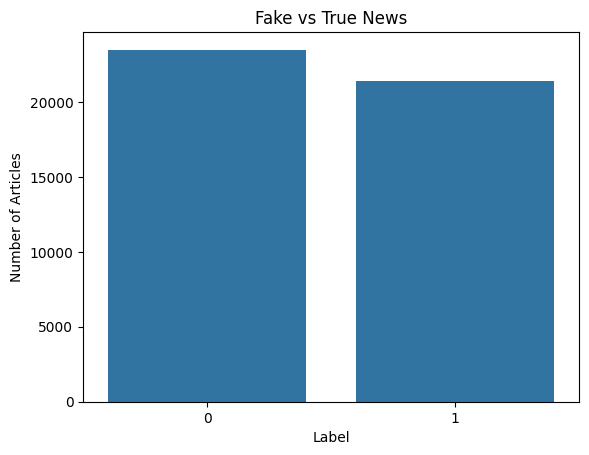

In [24]:
# Visualization of class distribution
sns.countplot(x='label', data=df)
plt.title('Fake vs True News')
plt.xlabel('Label')
plt.ylabel('Number of Articles')
plt.show()

In [25]:
X = df['text']
y = df['label']

In [26]:
X.head()

,text
0,"21st Century Wire says Ben Stein, reputable pr..."
1,WASHINGTON (Reuters) - U.S. President Donald T...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...
3,"On Monday, Donald Trump once again embarrassed..."
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid..."


In [27]:
y.head()

,label
0,0
1,1
2,1
3,0
4,1


In [28]:
print(df['text'].isnull().sum())
# no missing values

0


##Removal of Punctuation

In [29]:
def remove_punctuation(text):
  punctuationless_text = ''.join([i for i in text if i not in string.punctuation])
  # Comparing each char in text against the punctuation list
  return punctuationless_text

In [30]:
df['text'].head()

,text
0,"21st Century Wire says Ben Stein, reputable pr..."
1,WASHINGTON (Reuters) - U.S. President Donald T...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...
3,"On Monday, Donald Trump once again embarrassed..."
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid..."


In [31]:
df['Punct_removed'] = df['text'].apply(remove_punctuation)

In [32]:
df['Punct_removed'].head()

,Punct_removed
0,21st Century Wire says Ben Stein reputable pro...
1,WASHINGTON Reuters US President Donald Trump ...
2,Reuters Puerto Rico Governor Ricardo Rossello...
3,On Monday Donald Trump once again embarrassed ...
4,GLASGOW Scotland Reuters Most US presidential...


## Lowercasing

In [33]:
df["lowercased"] = [text.lower() for text in df["Punct_removed"]]

In [34]:
df['lowercased'].head()

,lowercased
0,21st century wire says ben stein reputable pro...
1,washington reuters us president donald trump ...
2,reuters puerto rico governor ricardo rossello...
3,on monday donald trump once again embarrassed ...
4,glasgow scotland reuters most us presidential...


## Tokenization

In [35]:
df['Tokens'] = df['lowercased'].apply(nltk.word_tokenize)

In [36]:
df['Tokens'].head()

,Tokens
0,"[21st, century, wire, says, ben, stein, reputa..."
1,"[washington, reuters, us, president, donald, t..."
2,"[reuters, puerto, rico, governor, ricardo, ros..."
3,"[on, monday, donald, trump, once, again, embar..."
4,"[glasgow, scotland, reuters, most, us, preside..."


## Stopwords removal

In [37]:
nltk.download('stopwords')
# get all the identified stopwords in english
stop_word_list = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
def remove_eng_stopword(text):
  filtered_text = [word for word in text if word not in stop_word_list]
  return filtered_text

In [39]:
df['Stpwrd_rem'] = df['Tokens'].apply(remove_eng_stopword)

In [40]:
df['Stpwrd_rem'].head()

,Stpwrd_rem
0,"[21st, century, wire, says, ben, stein, reputa..."
1,"[washington, reuters, us, president, donald, t..."
2,"[reuters, puerto, rico, governor, ricardo, ros..."
3,"[monday, donald, trump, embarrassed, country, ..."
4,"[glasgow, scotland, reuters, us, presidential,..."


## Stemming

In [41]:
stem_obj = PorterStemmer()
def stemming(clean_tokens):
  stem_list = [stem_obj.stem(word) for word in clean_tokens]
  return stem_list


In [42]:
df['stemmed'] = df['Stpwrd_rem'].apply(stemming)

In [43]:
df['stemmed'].head()

,stemmed
0,"[21st, centuri, wire, say, ben, stein, reput, ..."
1,"[washington, reuter, us, presid, donald, trump..."
2,"[reuter, puerto, rico, governor, ricardo, ross..."
3,"[monday, donald, trump, embarrass, countri, ac..."
4,"[glasgow, scotland, reuter, us, presidenti, ca..."


# Lemmatization

In [44]:
nltk.download('wordnet')
lemma_obj = WordNetLemmatizer()
def lemmatizating(text):
  lemma_list = [lemma_obj.lemmatize(word) for word in text]
  return lemma_list

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [45]:
df['Lemma_text'] = df['Stpwrd_rem'].apply(lemmatizating)

In [46]:
df['Lemma_text'].head()

,Lemma_text
0,"[21st, century, wire, say, ben, stein, reputab..."
1,"[washington, reuters, u, president, donald, tr..."
2,"[reuters, puerto, rico, governor, ricardo, ros..."
3,"[monday, donald, trump, embarrassed, country, ..."
4,"[glasgow, scotland, reuters, u, presidential, ..."


In [47]:
df['clean_txt'] = df['Lemma_text'].apply(lambda x: " ".join(x))
df['clean_txt'].head()

,clean_txt
0,21st century wire say ben stein reputable prof...
1,washington reuters u president donald trump re...
2,reuters puerto rico governor ricardo rossello ...
3,monday donald trump embarrassed country accide...
4,glasgow scotland reuters u presidential candid...


In [48]:
df.head()

,title,text,subject,date,label,Punct_removed,lowercased,Tokens,Stpwrd_rem,stemmed,Lemma_text,clean_txt
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0,21st Century Wire says Ben Stein reputable pro...,21st century wire says ben stein reputable pro...,"[21st, century, wire, says, ben, stein, reputa...","[21st, century, wire, says, ben, stein, reputa...","[21st, centuri, wire, say, ben, stein, reput, ...","[21st, century, wire, say, ben, stein, reputab...",21st century wire say ben stein reputable prof...
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1,WASHINGTON Reuters US President Donald Trump ...,washington reuters us president donald trump ...,"[washington, reuters, us, president, donald, t...","[washington, reuters, us, president, donald, t...","[washington, reuter, us, presid, donald, trump...","[washington, reuters, u, president, donald, tr...",washington reuters u president donald trump re...
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1,Reuters Puerto Rico Governor Ricardo Rossello...,reuters puerto rico governor ricardo rossello...,"[reuters, puerto, rico, governor, ricardo, ros...","[reuters, puerto, rico, governor, ricardo, ros...","[reuter, puerto, rico, governor, ricardo, ross...","[reuters, puerto, rico, governor, ricardo, ros...",reuters puerto rico governor ricardo rossello ...
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0,On Monday Donald Trump once again embarrassed ...,on monday donald trump once again embarrassed ...,"[on, monday, donald, trump, once, again, embar...","[monday, donald, trump, embarrassed, country, ...","[monday, donald, trump, embarrass, countri, ac...","[monday, donald, trump, embarrassed, country, ...",monday donald trump embarrassed country accide...
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1,GLASGOW Scotland Reuters Most US presidential...,glasgow scotland reuters most us presidential...,"[glasgow, scotland, reuters, most, us, preside...","[glasgow, scotland, reuters, us, presidential,...","[glasgow, scotland, reuter, us, presidenti, ca...","[glasgow, scotland, reuters, u, presidential, ...",glasgow scotland reuters u presidential candid...


## TF-IDF

In [49]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_txt'])

y = df['label']

print("Shape of TF-IDF Matrix:", X.shape)

Shape of TF-IDF Matrix: (44898, 5000)


## Data Splitting

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

1. The removal of punctuation and stopwords had the greatest impact
2. Doesnt have much effect on dentiment or contextual meaning
3. No stemming and lemmatization produce different result as stemming to to remove prefix and suffix whereas lemmatization is used to change to root word

# Model building

In [53]:

lr = LogisticRegression(max_iter=2000,random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [56]:
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred, average='weighted')
recall_lr = recall_score(y_test, y_pred, average='weighted')
f1_lr = f1_score(y_test, y_pred, average='weighted')
roc_auc_lr = roc_auc_score(y_test, y_pred)

In [61]:
print(accuracy_lr)
print(precision_lr)
print(recall_lr)
print(f1_lr)
print(roc_auc_lr)

0.9863028953229399
0.9863373934619161
0.9863028953229399
0.9863051405052768
0.9864531985423358


In [54]:
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm= svm.predict(X_test)

In [57]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)

In [60]:
print(accuracy_svm)
print(precision_svm)
print(recall_svm)
print(f1_svm)
print(roc_auc_svm)

0.9939866369710467
0.9939872760986449
0.9939866369710467
0.9939867589211956
0.9939944319579053


In [59]:
dec = DecisionTreeClassifier()
dec.fit(X_train, y_train)
y_pred_dec= dec.predict(X_test)

In [62]:
accuracy_dec = accuracy_score(y_test, y_pred_dec)
precision_dec = precision_score(y_test, y_pred_dec, average='weighted')
recall_dec = recall_score(y_test, y_pred_dec, average='weighted')
f1_dec = f1_score(y_test, y_pred_dec, average='weighted')
roc_auc_dec = roc_auc_score(y_test, y_pred_dec)

In [63]:
print(accuracy_dec)
print(precision_dec)
print(recall_dec)
print(f1_dec)
print(roc_auc_dec)

0.9957683741648107
0.9957714036159765
0.9957683741648107
0.9957681065741413
0.9956980094706821


1. Accuracy can be misleading in case of imabalanced dataset as it provide biased result leading to unidentification of fake news
2. The decision tree model is best as it have the highest recall precision and f1 score.
3. I would prioritize recall as we cant afford to spread a fake news by classifying it as real news

# Confusion Matrix

In [64]:
confusion_matrix =  confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[4617   79]
 [  44 4240]]


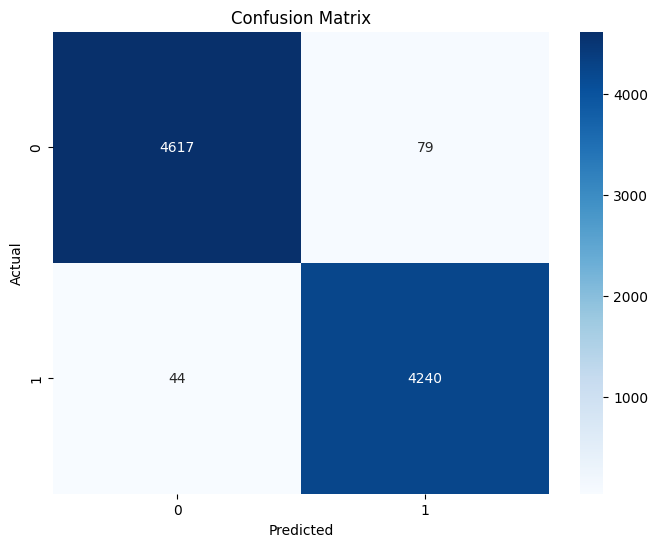

In [75]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [65]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



# Error analysis and model interpretation

In [66]:
misclassified_indices = np.where(y_test.values != y_pred)[0]

print("Total misclassified articles:", len(misclassified_indices))

Total misclassified articles: 123


In [67]:
selected_indices = misclassified_indices[:15]

print("Selected articles:", len(selected_indices))

Selected articles: 15


In [83]:
misclassified_df = pd.DataFrame({
    'Actual': y_test.iloc[selected_indices].values,
    'Predicted': y_pred[selected_indices],
    'Text': df.loc[y_test.index[selected_indices], 'clean_txt'].values
})

misclassified_df

,Actual,Predicted,Text
0,0,1,president trump arrived like bos check going n...
1,0,1,nervous nancy pelosi responded thursday critic...
2,0,1,religion peace spends spring break jihadis att...
3,1,0,oslo reuters following text nobel peace prize ...
4,1,0,washington reuters u president barack obama fo...
5,1,0,vatican city reuters pope francis wednesday ch...
6,1,0,reuters class 2012 grew parent grandparent cou...
7,0,1,obama released statement position regarding is...
8,0,1,obama added million onto taxpayer tab trip cub...
9,0,1,michigan court appeal rejected green party can...


In [77]:
feature_names = np.array(tfidf.get_feature_names_out())

In [80]:
coefficients = dec.feature_importances_

In [84]:
true_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

true_features = true_features.sort_values(
    by='Coefficient',
    ascending=False
)

print("Top features associated with true news:")
display(true_features.head(20))


Top features associated with TRUE news:


,Feature,Coefficient
3834,reuters,0.973072
61,21wiretv,0.002075
2271,image,0.001843
4797,via,0.001135
531,barack,0.000806
2171,hillary,0.000798
4995,zika,0.000777
3931,saidthe,0.000710
2028,government,0.000650
1307,demographic,0.000565


In [86]:
fake_features = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

fake_features = fake_features.sort_values(
    by='Coefficient',
    ascending=True
)

print("Top features related to fake news:")
display(fake_features.head(20))

Top features related to fake news:


,Feature,Coefficient
3278,patrick,0.0
3287,peaceful,0.0
3286,peace,0.0
3285,payment,0.0
3284,paying,0.0
3283,pay,0.0
3282,paul,0.0
3281,pattern,0.0
3280,patrol,0.0
3279,patriot,0.0


1. some wordsare influencial
2. hard
3. yes